### Data Extraction

Step 1: Load and verify data containing a log of events showing every time a passenger train passed through or stopped at a "measurement point" on the Belgian rail network.

In [11]:
# Library imports

import pandas as pd

# Load data from both August and September 2025

infrabel_raw_data = pd.concat(
    [
        pd.read_csv("data/Data_raw_punctuality_202508.csv"),
        pd.read_csv("data/Data_raw_punctuality_202509.csv").drop(labels = "OP1_COD", axis = 1)
    ]
)

# Data integrity check

infrabel_raw_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3877477 entries, 0 to 2015605
Data columns (total 21 columns):
 #   Column              Dtype  
---  ------              -----  
 0   DATDEP              object 
 1   CIRC_TYP            int64  
 2   TRAIN_NO            int64  
 3   RELATION            object 
 4   TRAIN_SERV          object 
 5   THOP1_COD           object 
 6   PTCAR_NO            int64  
 7   PTCAR_LG_NM_NL      object 
 8   LINE_NO_DEP         object 
 9   REAL_DATE_ARR       object 
 10  REAL_TIME_ARR       object 
 11  REAL_DATE_DEP       object 
 12  REAL_TIME_DEP       object 
 13  PLANNED_DATE_ARR    object 
 14  PLANNED_TIME_ARR    object 
 15  PLANNED_TIME_DEP    object 
 16  PLANNED_DATE_DEP    object 
 17  DELAY_ARR           float64
 18  DELAY_DEP           float64
 19  RELATION_DIRECTION  object 
 20  LINE_NO_ARR         object 
dtypes: float64(2), int64(3), object(16)
memory usage: 650.8+ MB


Step 2: Load and verify data containing distances (in kilometers) between adjacent stations.

In [2]:
# Load table containing distances between adjacent stations

infrabel_station_dist = pd.read_parquet("data/station_to_station.parquet")

# Data integrity check

infrabel_station_dist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1385 entries, 0 to 1384
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   geo_shape         1385 non-null   object 
 1   stationfrom_id    1385 non-null   object 
 2   stationfrom_name  1385 non-null   object 
 3   stationto_id      1385 non-null   object 
 4   stationto_name    1385 non-null   object 
 5   length            1385 non-null   float64
 6   geo_point_2d      1385 non-null   object 
dtypes: float64(1), object(6)
memory usage: 75.9+ KB


### Data Preparation

Step 1: Creating datetime objects for planned and actual arrivals and departures.

In [3]:
# Create datetime strings for planned and actual event times

infrabel_raw_data["planned_datetime_arr"] = (infrabel_raw_data["PLANNED_DATE_ARR"] + " " + infrabel_raw_data["PLANNED_TIME_ARR"])
infrabel_raw_data["planned_datetime_dep"] = (infrabel_raw_data["PLANNED_DATE_DEP"] + " " + infrabel_raw_data["PLANNED_TIME_DEP"])
infrabel_raw_data["actual_datetime_arr"] = (infrabel_raw_data["REAL_DATE_ARR"] + " " + infrabel_raw_data["REAL_TIME_ARR"])
infrabel_raw_data["actual_datetime_dep"] = (infrabel_raw_data["REAL_DATE_DEP"] + " " + infrabel_raw_data["REAL_TIME_DEP"])

# Verify the columns were populated correctly

print(
    infrabel_raw_data[
        [
            "planned_datetime_arr",
            "planned_datetime_dep",
            "actual_datetime_arr",
            "actual_datetime_dep"
        ]
    ]
)

NameError: name 'infrabel_raw_data' is not defined

In [ ]:
# Convert newly-created datetime string cols to Pandas datetime objects

infrabel_raw_data[
    [
        "planned_datetime_arr",
        "planned_datetime_dep",
        "actual_datetime_arr",
        "actual_datetime_dep"
    ]
] = (
    infrabel_raw_data[
        [
            "planned_datetime_arr",
            "planned_datetime_dep",
            "actual_datetime_arr",
            "actual_datetime_dep"
        ]
    ]
    .map(
        lambda x:
        pd.to_datetime(
            x,
            format = "mixed",
            dayfirst = True
        )
    )
)

# Verify the strings were converted to datetime objects

print(
    infrabel_raw_data[
        [
            "planned_datetime_arr",
            "planned_datetime_dep",
            "actual_datetime_arr",
            "actual_datetime_dep"
        ]
    ]
)

        planned_datetime_arr planned_datetime_dep actual_datetime_arr actual_datetime_dep
0        2025-08-01 20:28:00  2025-08-01 20:28:00 2025-08-01 20:30:46 2025-08-01 20:30:46
1        2025-08-01 20:39:00  2025-08-01 20:39:00 2025-08-01 20:42:44 2025-08-01 20:42:44
2        2025-08-01 20:40:00  2025-08-01 20:40:00 2025-08-01 20:43:41 2025-08-01 20:43:41
3        2025-08-01 20:43:00  2025-08-01 20:46:00 2025-08-01 20:46:01 2025-08-01 20:48:36
4        2025-08-01 20:51:00  2025-08-01 20:51:00 2025-08-01 20:52:28 2025-08-01 20:52:28
...                      ...                  ...                 ...                 ...
2015601  2025-09-30 21:23:00  2025-09-30 21:24:00 2025-09-30 21:22:56 2025-09-30 21:23:59
2015602  2025-09-30 21:28:00  2025-09-30 21:29:00 2025-09-30 21:27:56 2025-09-30 21:30:21
2015603  2025-09-30 21:33:00  2025-09-30 21:34:00 2025-09-30 21:33:12 2025-09-30 21:34:19
2015604  2025-09-30 21:43:00  2025-09-30 21:44:00 2025-09-30 21:42:53 2025-09-30 21:44:01
2015605  2

Calculate actual and expected dwell times from the datetime objects.

In [ ]:
# Calculates planned dwell time in seconds

infrabel_raw_data["planned_dwell_time"] = (
    (infrabel_raw_data["planned_datetime_dep"] - infrabel_raw_data["planned_datetime_arr"])
    .map(
        lambda x:
        x.total_seconds()
    )
)

# Calculates actual dwell time in seconds

infrabel_raw_data["actual_dwell_time"] = (
    (infrabel_raw_data["actual_datetime_dep"] - infrabel_raw_data["actual_datetime_arr"])
    .map(
        lambda x:
        x.total_seconds()
    )
)

# Verify the planned and actual dwell times were calculated correctly

print(
    infrabel_raw_data[
        [
            "planned_dwell_time",
            "actual_dwell_time"
        ]
    ]
)

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <positron.positron_ipkernel.PositronIPyKernel object at 0x11a3c74d0>>
Traceback (most recent call last):
  File "/Applications/Positron.app/Contents/Resources/app/extensions/positron-python/python_files/lib/ipykernel/py3/ipykernel/ipkernel.py", line 796, in _clean_thread_parent_frames
    active_threads = {thread.ident for thread in threading.enumerate()}
  File "/opt/miniconda3/lib/python3.13/threading.py", line 1480, in enumerate
    def enumerate():
KeyboardInterrupt: 


         planned_dwell_time  actual_dwell_time
0                       0.0                0.0
1                       0.0                0.0
2                       0.0                0.0
3                     180.0              155.0
4                       0.0                0.0
...                     ...                ...
2015601                60.0               63.0
2015602                60.0              145.0
2015603                60.0               67.0
2015604                60.0               68.0
2015605                 NaN                NaN

[3877477 rows x 2 columns]

KeyboardInterrupt: 

In [ ]:
# Save checkpoint file

infrabel_raw_data.to_parquet(
    "data/infrabel_data_checkpoint_dwell.parquet"
)

Transform the station dataset to ensure it is possible to calculate station to station distances and velocities for future cleaning tasks (also curiosity).

In [ ]:
## Perform transformations on the station dataset

inverse_infrabel_station_dist = (
    infrabel_station_dist.copy()
        .rename(
            columns = {
                "stationfrom_id": "station_to_id",
                "stationto_id": "station_from_id"
            }
        )
        .drop(
            labels = [
                "geo_shape",
                "geo_point_2d",
                "stationfrom_name",
                "stationto_name"
            ],
            axis = 1
        )
        [["station_from_id", "station_to_id", "length"]]
)

infrabel_station_dist = (
    infrabel_station_dist.copy()
        .rename(
            columns = {
                "stationfrom_id": "station_from_id",
                "stationto_id": "station_to_id"
            }
        )
        .drop(
            labels = [
                "geo_shape",
                "geo_point_2d",
                "stationfrom_name",
                "stationto_name"
            ],
            axis = 1
        )
)

infrabel_station_dist_concat = (
    pd.concat(
        [
            infrabel_station_dist,
            inverse_infrabel_station_dist
        ]
    )
        .drop_duplicates(
            subset = ["station_to_id", "station_from_id"]
        )
)

# Create a list of unique station measurement points

station_mps = list(
    map(
        lambda x: int(x),
        list(
            infrabel_station_dist_concat
            ["station_from_id"]
            .unique()
        )
    )
)

# Type cast station IDs to float

infrabel_station_dist_concat[["station_to_id", "station_from_id"]] = (
    infrabel_station_dist_concat[["station_to_id", "station_from_id"]].map(float)
)

Filter event log for events where the measurement point ID (**PTCAR_NO**) is a train station

In [ ]:
# Load checkpoint file

infrabel_raw_data = pd.read_parquet(
    "data/infrabel_data_checkpoint_dwell.parquet"
)

# Filter for events where the value of "planned_dwell_time" != 0
# (Captures stops and origins/destinations)

infrabel_raw_data = (
    infrabel_raw_data
        [infrabel_raw_data["PTCAR_NO"].map(lambda x: x in station_mps)]
        .reset_index(
            drop = True
        )
)

# Save checkpoint file

infrabel_raw_data.to_parquet(
    "data/infrabel_data_checkpoint_filtered.parquet"
)

Step 4: Calculate the difference between planned and expected arrival and departure times and the difference between those values (i.e. the difference between planned and actual dwell time).

In [ ]:
# Load checkpoint file

infrabel_raw_data = pd.read_parquet(
    "data/infrabel_data_checkpoint_filtered.parquet"
)

# Calculate the difference between actual and expected arrival times

infrabel_raw_data["arrival_time_diff"] = (
    (infrabel_raw_data["actual_datetime_arr"] - infrabel_raw_data["planned_datetime_arr"])
    .map(
        lambda x:
        (x.total_seconds() if pd.isna(x) is False else 0)
    )
)

# Calculate the difference between planned and actual departure times

infrabel_raw_data["departure_time_diff"] = (
    (infrabel_raw_data["actual_datetime_dep"] - infrabel_raw_data["planned_datetime_dep"])
    .map(
        lambda x:
        x.total_seconds()
    )
)

# Calculate the difference between the differences between
# planned and actual arrival and departure times

infrabel_raw_data["arrival_departure_diff"] = (infrabel_raw_data["departure_time_diff"] - infrabel_raw_data["arrival_time_diff"])

In [ ]:
# Save checkpoint file after initial transformations

infrabel_raw_data.to_parquet(
    "data/infrabel_data_checkpoint.parquet"
)

Step 5: Iterate over the dataset to assign unique IDs to each run of each train number. (Note: While this may seem inefficient compared to subsetting based on train number and date of departure, some trains span two days -- i.e. late night trains that start before midnight and end after -- and would otherwise be omitted as legitimate data points despite being valid.)

In [ ]:
# Load checkpoint file

infrabel_raw_data = pd.read_parquet("data/infrabel_data_checkpoint.parquet")

# Begin iteration

for obs in range(len(infrabel_raw_data)):
    if obs == 0:
        train_id = 1
    else:
        if infrabel_raw_data.loc[(obs - 1, "TRAIN_NO")] != infrabel_raw_data.loc[(obs, "TRAIN_NO")]:
            train_id = train_id + 1
        else:
            ...
        
    infrabel_raw_data.loc[(obs, "train_id")] = train_id

# Verify the unique train IDs were populated correctly

print(infrabel_raw_data["train_id"])

# Output checkpoint file

infrabel_raw_data.to_parquet(
    "data/infrabel_data_checkpoint_uuid.parquet"
)

0               1.0
1               1.0
2               1.0
3               1.0
4               1.0
             ...   
3651751    206283.0
3651752    206283.0
3651753    206283.0
3651754    206283.0
3651755    206283.0
Name: train_id, Length: 3651756, dtype: float64


In [ ]:
## Calculate expected and actual travel times between stations

# (a) Load checkpoint file

infrabel_raw_data = pd.read_parquet(
    "data/infrabel_data_checkpoint_uuid.parquet"
)

# (b) Iterate over each unique train run ID (train_id)

def calculate_travel_times(
    run_df: pd.DataFrame,
    stop_no: int = 1
) -> pd.DataFrame:
    for obs in range(len(run_df)):
        if obs == 0:
            run_df.loc[(0, "station_from_id")] = run_df.loc[(0, "PTCAR_NO")]
            run_df.loc[(0, "planned_travel_time")] = None
            run_df.loc[(0, "actual_travel_time")] = None
            run_df.loc[(0, "dwell_time_diff_prev")] = run_df.loc[(0, "arrival_departure_diff")]

            if run_df.loc[(obs, "planned_dwell_time")] > 0:
                stop_no = stop_no + 1
            else:
                ...

        else:
            # Add station_from_id (to merge adjacent station distances)

            run_df.loc[(obs, "station_from_id")] = run_df.loc[(obs - 1, "PTCAR_NO")]

            # Calculate planned travel time between stations

            run_df.loc[(obs, "planned_travel_time")] = (
                (run_df.loc[(obs, "planned_datetime_arr")] - run_df.loc[(obs - 1, "planned_datetime_dep")])
                    .total_seconds()
            )

            # Calculate actual travel time between stations
            
            run_df.loc[(obs, "actual_travel_time")] = (
                (run_df.loc[(obs, "actual_datetime_arr")] - run_df.loc[(obs - 1, "actual_datetime_dep")])
                    .total_seconds()
            )


            # Increment stop number if planned dwell time exceeded 0
            # for the preceding station/measurement point

            if run_df.loc[(obs - 1, "planned_dwell_time")] > 0:
                stop_no = stop_no + 1
            elif run_df.loc[(obs, "planned_dwell_time")] > 0:
                if stop_no == 1:
                    run_df.loc[(obs, "dwell_time_diff_prev")] = run_df.loc[(0, "dwell_time_diff_prev")]
                else:
                    ...
            else:
                ...

        # Populate the stop number column

        run_df.loc[(obs, "stop_id")] = stop_no

    return (
        run_df
            .rename(
                columns = {
                    "PTCAR_NO": "station_to_id"
                }
            )
            .drop(
                labels = [
                    "DATDEP",
                    "CIRC_TYP",
                    "RELATION",
                    "TRAIN_SERV",
                    "THOP1_COD",
                    "LINE_NO_DEP",
                    "REAL_DATE_ARR",
                    "REAL_DATE_DEP",
                    "REAL_TIME_ARR",
                    "REAL_TIME_DEP",
                    "PLANNED_DATE_ARR",
                    "PLANNED_DATE_DEP",
                    "DELAY_ARR",
                    "DELAY_DEP",
                    "RELATION_DIRECTION",
                    "LINE_NO_ARR"
                ],
                axis = 1,
                inplace = False
            )
    )

infrabel_raw_data = pd.concat(
    list(
        map(
            lambda run_df: calculate_travel_times(run_df = run_df),
            [
                (
                    run_tuple[1]
                        .reset_index(
                            drop = True
                        )
                )
                for run_tuple
                in (
                    infrabel_raw_data
                        .groupby(
                            pd.Grouper(
                                key = "train_id"
                            )
                        )
                )
            ]
        )
    )
)

# Output checkpoint file

infrabel_raw_data.to_parquet(
    "data/infrabel_data_checkpoint_durations.parquet"
)

In [ ]:
## Append distances between adjacent stations and calculate average velocity

# (a) Load checkpoint file

infrabel_raw_data = pd.read_parquet(
    "data/infrabel_data_checkpoint_durations.parquet"
)

# (b) Drop all null durations and rename the variable
# "PTCAR_NO" to "station_to_id" for outer join

infrabel_raw_data = (
    infrabel_raw_data
        [infrabel_raw_data["actual_travel_time"].map(lambda x: x == None or pd.isnull(x) == False)]
        .reset_index(
            drop = True
        )
        .rename(
            columns = {
                "PTCAR_NO": "station_to_id"
            }
        )
)

# (c) Outer join distances (in km) between adjacent stations to
# the table

infrabel_raw_data = (
    pd.merge(
        left = infrabel_raw_data,
        right = infrabel_station_dist_concat,
        how = "left",
        on = [
            "station_to_id",
            "station_from_id"
        ]
    )
)

# (d) Save checkpoint file

infrabel_raw_data.to_parquet(
    "data/infrabel_data_checkpoint_distances.parquet"
)


Calculate the average velocity between stops (sum distance for each stop)

In [ ]:
# (a) Load distances checkpoint file

infrabel_raw_data = pd.read_parquet(
    "data/infrabel_data_checkpoint_distances.parquet"
)

# (b) Aggregate distances

infrabel_raw_test = (
    infrabel_raw_data
        [["train_id", "stop_id", "length", "planned_travel_time", "actual_travel_time"]]
        .groupby(
            by = [
                "train_id",
                "stop_id"
            ],
            as_index = False
        )
        .agg(
            func = "sum"
        )
        .reset_index(
            drop = True
        )        
)

# (c) Drops measurement points with out of bounds (within the
# context of this analysis) actual and planned dwell times

infrabel_raw_data = (
    infrabel_raw_data
        [infrabel_raw_data["actual_dwell_time"] > 0]
        [infrabel_raw_data["planned_dwell_time"] > 0]
        .drop(
            labels = ["length", "planned_travel_time", "actual_travel_time"],
            axis = 1
        )
        .reset_index(
            drop = True
        )
)

# (d) Join datasets

infrabel_raw_data = (
    pd.merge(
        left = infrabel_raw_data,
        right = infrabel_raw_test,
        how = "left",
        on = [
            "train_id",
            "stop_id"
        ]
    )
)

# Save checkpoint file

infrabel_raw_data.to_parquet(
    "data/infrabel_data_checkpoint_lengths.parquet"
)

<positron-console-cell-98>:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.


Calculate features 1.A ("Difference between planned and actual dwell time at preceding station (seconds)") and 1.C ("Difference between planned and actual travel time on the preceding track segment (seconds)")

In [ ]:
## Calculate expected and actual travel times between stations

# (a) Load checkpoint file

infrabel_raw_data = pd.read_parquet(
    "data/infrabel_data_checkpoint_lengths.parquet"
)

# (b) Iterate over each unique train run ID (train_id)

def calculate_prev_dwell(
    run_df: pd.DataFrame
) -> pd.DataFrame:

    run_df["travel_time_diff_prev"] = (
        run_df["actual_travel_time"] - run_df["planned_travel_time"]
    )

    for obs in range(1, len(run_df)):
        run_df.loc[(obs, "dwell_time_diff_prev")] = run_df.loc[obs - 1, "arrival_departure_diff"]  # 1.A

    return run_df

infrabel_raw_data = pd.concat(
    list(
        map(
            lambda run_df: calculate_prev_dwell(run_df = run_df),
            [
                (
                    run_tuple[1]
                        .reset_index(
                            drop = True
                        )
                )
                for run_tuple
                in (
                    infrabel_raw_data
                        .groupby(
                            pd.Grouper(
                                key = "train_id"
                            )
                        )
                )
            ]
        )
    )
)

# Output checkpoint file

infrabel_raw_data.to_parquet(
    "data/infrabel_data_checkpoint_run_done.parquet"
)

Because all of the relevant features (1.A and 1.C) have been calculated, the binary/categorical equivalents (2.A and 2.C) need to be calculated, along with multi-hour bins (1.E, 1.F, & 1.G) and velocities.

In [ ]:
## Load last checkpoint

infrabel_raw_data = pd.read_parquet(
    "data/infrabel_data_checkpoint_run_done.parquet"
)

# Rename features 1A and 1C

infrabel_raw_data = (
    infrabel_raw_data
        .rename(
            columns = {
                "dwell_time_diff_prev": "_1A",
                "travel_time_diff_prev": "_1C"
            }
        )
)

## Calculate binary features

infrabel_raw_data[["_2A"]] = infrabel_raw_data[["_1A"]] > 0
infrabel_raw_data[["_2C"]] = infrabel_raw_data[["_1C"]] > 0

# Create multi-hour bins

infrabel_raw_data[["_1E"]] = infrabel_raw_data[["actual_datetime_arr"]].map(lambda x: (x.hour // 2) * 2)
infrabel_raw_data[["_1F"]] = infrabel_raw_data[["actual_datetime_arr"]].map(lambda x: (x.hour // 3) * 3)
infrabel_raw_data[["_1G"]] = infrabel_raw_data[["actual_datetime_arr"]].map(lambda x:( x.hour // 4) * 4)

## Save checkpoint file

infrabel_raw_data.to_parquet(
    "data/infrabel_data_checkpoint_featureset1.parquet"
)

Calculate velocities and clean extreme values for velocity and (planned and actual) dwell times.

In [ ]:
## Relevant library import

import pandas as pd
import scipy

## Load checkpoint file

infrabel_raw_data = pd.read_parquet(
    "data/infrabel_data_checkpoint_featureset1.parquet"
)

# Reset index

infrabel_raw_data = (
    infrabel_raw_data
        .reset_index(
            drop = True
        )
)

## Calculate velocities

infrabel_raw_data["vel"] = infrabel_raw_data["length"] / (infrabel_raw_data["actual_travel_time"] / 3600)

## Remove extreme velocities

# (a) Remove negative velocities and velocities of 0 km/h

infrabel_raw_data = (
    infrabel_raw_data
        [infrabel_raw_data["vel"] > 0]
)

# (b) Remove extreme low velocities

# Set high and low cutoff thresholds

infrabel_raw_data["vel_penalized"] = (infrabel_raw_data["vel"] / infrabel_raw_data["actual_travel_time"])

high_vel = infrabel_raw_data["vel_penalized"].quantile(q = 0.999) 
low_vel = infrabel_raw_data["vel_penalized"].quantile(q = 0.001)

# Remove values beyond the cutoffs

infrabel_raw_data = (
    infrabel_raw_data
        [infrabel_raw_data["vel_penalized"] <= high_vel]
        [infrabel_raw_data["vel_penalized"] >= low_vel]
)

# Drop velocity (and length and penalized velocity) from the table

infrabel_raw_data = (
    infrabel_raw_data
        .drop(
            labels = [
                "length",
                "vel",
                "vel_penalized"
            ],
            axis = 1
        )
        .reset_index(
            drop = True
        )
)

## Save checkpoint file

infrabel_raw_data.to_parquet(
    "data/infrabel_data_checkpoint_cleaned.parquet"
)

<positron-console-cell-101>:46: UserWarning: Boolean Series key will be reindexed to match DataFrame index.


Add feature 1.H (Train operator) and features 1.I (departure day of week) and 2.I (whether the train departed on a weekend) to the table before calculating single station features.

In [ ]:
## Load last checkpoint

infrabel_raw_data = pd.read_parquet(
    "data/infrabel_data_checkpoint_cleaned.parquet"
)

## Load full table with IDs (legitimately forgot this would be important)

infrabel_data_w_ids = pd.read_parquet(
    "data/infrabel_data_checkpoint_uuid.parquet"
)

# Subsets for relevant cols and creates feature 1.H

infrabel_data_w_ids = (
    infrabel_data_w_ids[["train_id", "TRAIN_SERV", "actual_datetime_arr"]]
        .dropna(
            subset = "actual_datetime_arr"
        )
        .drop_duplicates(
            subset = [
                "train_id",
                "TRAIN_SERV"
            ]
        )
        .reset_index(
            drop = True
        )
)

# Convert "actual_datetime_arr" to day of the week (feature 1.I)

infrabel_data_w_ids["actual_datetime_arr"] = (
    infrabel_data_w_ids["actual_datetime_arr"].map(lambda x: x.isoweekday())
)

# Convert ISO day of week to binary feature calculating whether a train
# has departed during a weekend (feature 2.I)

infrabel_data_w_ids["_2I"] = infrabel_data_w_ids["actual_datetime_arr"].map(lambda x: x in [6, 7])

# Convert columns to new feature names

infrabel_data_w_ids = (
    infrabel_data_w_ids
        .rename(
            columns = {
                "TRAIN_SERV": "_1H",
                "actual_datetime_arr": "_1I"
            }
        )
)

## Merge datasets together

infrabel_raw_data = (
    pd.merge(
        left = infrabel_raw_data,
        right = infrabel_data_w_ids,
        how = "left",
        on = [
            "train_id"
        ]
    )
)

## Save checkpoint file

infrabel_raw_data.to_parquet(
    "data/infrabel_data_checkpoint_featureset2.parquet"
)

Calculate the final relevant features for prediction: 1.B (The difference between planned and actual dwell time for the preceding valid train at the same station) and 1.D (Time since the last valid train stopped at the same station).

In [ ]:
## Load most recent checkpoint file

infrabel_raw_data = pd.read_parquet(
    "data/infrabel_data_checkpoint_featureset2.parquet"
)

## Defines lambda function

def calculate_station_feats(
    station_df: int
) -> pd.DataFrame:
    for obs in range(1, len(station_df)):

        # "Difference between planned and actual dwell time for the preceding valid train at the
        # same station"

        station_df.loc[(obs, "_1B")] = station_df.loc[(obs - 1, "arrival_departure_diff")]
        station_df.loc[(obs, "_1D")] = (station_df.loc[(obs, "actual_datetime_arr")] - station_df.loc[(obs - 1, "actual_datetime_arr")]).total_seconds()

    return station_df

## Calculates features 1.B and 1.D

infrabel_raw_data = pd.concat(
    list(
        map(
            lambda station_df: calculate_station_feats(station_df = station_df),
            [
                (
                    station_tuple[1]
                        .sort_values(
                            by = "actual_datetime_arr",
                            ascending = True
                        )
                        .reset_index(
                            drop = True
                        )
                )
                for station_tuple
                in (
                    infrabel_raw_data
                        .groupby(
                            pd.Grouper(
                                key = "station_to_id"
                            )
                        )
                )
            ]
        )
    )
)

# Resets index on the concatenated dataset

infrabel_raw_data = infrabel_raw_data.reset_index(drop = True)

## Calculate binary features 2.B and 2.D

# Calculate 2.B

infrabel_raw_data["_2B"] = infrabel_raw_data["_1B"].map(lambda x: x > 0)

# Sets 50th percentile cutoff for 2.D

percentile_50_cutoff = infrabel_raw_data["_1D"].quantile(q = 0.5)

# Calculates 2.D

infrabel_raw_data["_2D"] = infrabel_raw_data["_1D"].map(lambda x: x > percentile_50_cutoff) 

## Save checkpoint file

infrabel_raw_data.to_parquet(
    "data/infrabel_data_checkpoint_featureset3.parquet"
)

Final clean-up and separation into two separate datasets (1 and 2).

In [ ]:
## Load previous checkpoint file

infrabel_raw_data = pd.read_parquet(
    "data/infrabel_data_checkpoint_featureset3.parquet"
)

## Remove null "1.A", "1.B", and "1.D" values

infrabel_raw_data = (
    infrabel_raw_data
        .dropna(
            subset = [
                "_1A",
                "_1B",
                "_1D"
            ]
        )
        .reset_index(
            drop = True
        )
)

## Rename target variable

infrabel_raw_data = (
    infrabel_raw_data
        .rename(
            columns = {
                "actual_dwell_time": "y"
            }
        )
)

## Create continuous prediction dataset

infrabel_processed_1 = (
    infrabel_raw_data[
        [
            "y",
            "_1A",
            "_1B",
            "_1C",
            "_1D",
            "_1E",
            "_1F",
            "_1G",
            "_1H",
            "_1I"
        ]
    ]
)

## Create categorical prediction dataset

infrabel_processed_2 = (
    infrabel_raw_data[
        [
            "y",
            "_2A",
            "_2B",
            "_2C",
            "_2D",
            "_1E",
            "_1F",
            "_1G",
            "_1H",
            "_2I"
        ]
    ]
)

## Save checkpoint files

infrabel_raw_data.to_parquet(
    "data/infrabel_data_checkpoint_final.parquet"
)
infrabel_processed_1.to_parquet(
    "data/infrabel_data_checkpoint_processed1.parquet"
)
infrabel_processed_2.to_parquet(
    "data/infrabel_data_checkpoint_processed2.parquet"
)

### Data Exploration

In [12]:
import pandas as pd
from plotnine import *
from plotnine import geom_histogram

## Load checkpoint file

infrabel_processed_data = pd.read_parquet(
    "data/infrabel_data_checkpoint_final.parquet"
)

## Calculate summary statistics

# Subset for relevant variables

infrabel_processed_data = (
    infrabel_processed_data
        [
            [
                
                "y",
                "_1A",
                "_1B",
                "_1C",
                "_1D",
                "_1E",
                "_1F",
                "_1G",
                "_1H",
                "_1I",
                "_2A",
                "_2B",
                "_2C",
                "_2D",
                "_2I"
            ]
        ]
)

# Map categorical columns to categories

(
    infrabel_processed_data
        [
            [
                "_1E",
                "_1F",
                "_1G",
                "_1H",
                "_1I",
                "_2A",
                "_2B",
                "_2C",
                "_2D",
                "_2I"
            ]
        ]
) = (
    infrabel_processed_data
        [
            [
                "_1E",
                "_1F",
                "_1G",
                "_1H",
                "_1I",
                "_2A",
                "_2B",
                "_2C",
                "_2D",
                "_2I"
            ]
        ]
        .map(
            lambda x:
            str(x)
        )
)

# Display descriptive statistics

desc_stats = infrabel_processed_data.describe(
    include = "all"
)

# Output desc stats to csv

desc_stats.to_csv(
    "data/infrabel_data_checkpoint_descstats.csv",
    index = True
)

### Predictive Modeling

#### Methodology

(1) Split each dataset into X and y variants for predictive modeling
(2) Train-test split (20-80) with random state 102
(3) Using ColumnTransformer:

- One hot encode 1.E, 1.F. 1.G, 1.H, and 1.I
- Standardize 1.A, 1.B, 1.C, and 1.D
- Remainder are passthrough

(4) Create param search grids for each model
(5) Use GridSearchCV with k = 20 folds for each model (random state 102)
(6) Train and fit the final model (random state 102)
(7) Calculate metrics and output median permutation importance

Step 1

In [13]:
## Load checkpoint datasets

infrabel_processed_1 = pd.read_parquet(
    "data/infrabel_data_checkpoint_processed1.parquet"
)
infrabel_processed_2 = pd.read_parquet(
    "data/infrabel_data_checkpoint_processed2.parquet"
)

## Create X and y dataframes for train_test_split

infrabel_processed_1_X = (
    infrabel_processed_1[
        [
            "_1A",
            "_1B",
            "_1C",
            "_1D",
            "_1E",
            "_1F",
            "_1G",
            "_1H",
            "_1I"
        ]
    ]
)
infrabel_processed_1_y = (
    infrabel_processed_1["y"]
)

infrabel_processed_2_X = (
    infrabel_processed_2[
        [
            "_2A",
            "_2B",
            "_2C",
            "_2D",
            "_1E",
            "_1F",
            "_1G",
            "_1H",
            "_2I"
        ]
    ]
)
infrabel_processed_2_y = (
    infrabel_processed_2["y"]
)

Step 2

In [14]:
## Import relevant modules

from sklearn.model_selection import train_test_split

## Apply train-test split to dataset 1 (continuous)

(
    X_train_1,
    X_test_1,
    y_train_1,
    y_test_1
) = train_test_split(
    infrabel_processed_1_X,
    infrabel_processed_1_y,
    test_size = 0.9,
    random_state = 102
)

## Apply train-test split to dataset 2 (categorical)

(
    X_train_2,
    X_test_2,
    y_train_2,
    y_test_2
) = train_test_split(
    infrabel_processed_2_X,
    infrabel_processed_2_y,
    test_size = 0.9,
    random_state = 102
)

Step 3

In [15]:
## Library imports

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction import DictVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

## Dataset 1 transformation pipeline

ct_1 = ColumnTransformer(
    transformers = [
        ("one_hot", OneHotEncoder(), [4, 5, 6, 7, 8]),
        ("standardize", StandardScaler(), [0, 1, 2, 3])
    ],
    verbose_feature_names_out = False
)

## Dataset 2 transformation pipeline

ct_2 = ColumnTransformer(
    transformers = [
        ("one_hot", OneHotEncoder(), [4, 5, 6, 7])
    ],
    remainder = "passthrough",
    verbose_feature_names_out = False
)

## Fit and transform X_train_1 and X_test_1

ct_1.fit(X_train_1)

X_1_transformed_cols = ct_1.get_feature_names_out()
X_train_1_transformed = ct_1.transform(X_train_1).toarray()
X_test_1_transformed = ct_1.transform(X_test_1).toarray()

## Fit and transform X_train_2 and X_test_2

ct_2.fit(X_train_2)

X_2_transformed_cols = ct_2.get_feature_names_out()
X_train_2_transformed = ct_2.transform(X_train_2).toarray()
X_test_2_transformed = ct_2.transform(X_test_2).toarray()


Step 4

In [101]:
## Set param search grids for each of the four model types in use

# XGBoostRegressor

param_grid_xgbr = {
    "n_estimators": [10, 20, 40, 80, 160],
    "max_depth": [2, 4, 8, 16, 32]
}

# AdaBoost/DecisionTreeRegressor

param_grid_dtr = {
    "max_depth": [2, 4, 8, 16, 32]
}

# AdaBoost/RandomForestRegressor

param_grid_rfr = {
    "n_estimators": [10, 20, 40, 80, 160],
    "max_depth": [2, 4, 8, 16, 32]
}

# GradientBoostingRegressor

param_grid_gbr = {
    "n_estimators": [10, 20, 40, 80, 160],
    "max_depth": [2, 4, 8, 16, 32],
}

Step 5

In [102]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

## XGBR - Dataset 1

# Init grid search

xgbr_1_cv = GridSearchCV(
    estimator = xgb.XGBRegressor(
        tree_method = "hist",
        random_state = 102
    ),
    param_grid = param_grid_xgbr,
    cv = 20,
    scoring = "r2",
    n_jobs = 6
)

xgbr_1_cv.fit(
    X = X_train_1_transformed,
    y = y_train_1
)

# Output best parameters

print(xgbr_1_cv.best_params_)

# Init XGBoost regressor

xgbr_1 = xgb.XGBRegressor(
    **xgbr_1_cv.best_params_,
    tree_method = "hist",
    random_state = 102
)

# Fit XGBoost regressor

xgbr_1.fit(
    X = X_train_1_transformed,
    y = y_train_1
)
xgbr_1_y_pred = xgbr_1.predict(X_test_1_transformed)

# Output relevant summary statistics

print(r2_score(y_true = y_test_1, y_pred = xgbr_1_y_pred))
print(mean_absolute_error(y_true = y_test_1, y_pred = xgbr_1_y_pred))
print(mean_absolute_percentage_error(y_true = y_test_1, y_pred = xgbr_1_y_pred))
print(root_mean_squared_error(y_true = y_test_1, y_pred = xgbr_1_y_pred))


/opt/miniconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.


{'max_depth': 8, 'n_estimators': 10}
0.16215439271747556
55.76676468679712
0.6498348624972232
111.39005511826541


In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

## DTR - Dataset 1

# Init grid search

dtr_1_cv = GridSearchCV(
    estimator = DecisionTreeRegressor(
        random_state = 102
    ),
    param_grid = param_grid_dtr,
    scoring = "r2",
    cv = 20,
    n_jobs = 6
)

dtr_1_cv.fit(
    X = X_train_1_transformed,
    y = y_train_1
)

# Report best params from grid search

print(
    dtr_1_cv.best_params_
)

{'max_depth': 8}


In [ ]:
# Fit and eval model using predictors from grid search

dtr_1 = DecisionTreeRegressor(
    max_depth = 8,
    random_state = 102
)
dtr_1.fit(
    X = X_train_1_transformed,
    y = y_train_1
)
dtr_1_y_pred = dtr_1.predict(
    X = X_test_1_transformed
)

# Output relevant summary statistics

print(r2_score(y_true = y_test_1, y_pred = dtr_1_y_pred))
print(mean_absolute_error(y_true = y_test_1, y_pred = dtr_1_y_pred))
print(mean_absolute_percentage_error(y_true = y_test_1, y_pred = dtr_1_y_pred))
print(root_mean_squared_error(y_true = y_test_1, y_pred = dtr_1_y_pred))

0.10732356589439052
57.24236092047512
0.6698291564959055
114.97712774172234


In [ ]:
from sklearn.ensemble import RandomForestRegressor 

## RFR - Dataset 1

# Init grid search

rfr_1_cv = GridSearchCV(
    estimator = RandomForestRegressor(
        random_state = 102
    ),
    param_grid = param_grid_rfr,
    scoring = "r2",
    cv = 20,
    n_jobs = 6
)

rfr_1_cv.fit(
    X = X_train_1_transformed,
    y = y_train_1
)

# Report best params from grid search

print(
    rfr_1_cv.best_params_
)

/opt/miniconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'max_depth': 16, 'n_estimators': 160}


In [ ]:
# Fit and eval model using predictors from grid search

rfr_1 = RandomForestRegressor(
    random_state = 102,
    max_depth = 16,
    n_estimators = 160
)
rfr_1.fit(
    X = X_train_1_transformed,
    y = y_train_1
)
rfr_1_y_pred = rfr_1.predict(
    X = X_test_1_transformed
)

# Output relevant summary statistics

print(r2_score(y_true = y_test_1, y_pred = rfr_1_y_pred))
print(mean_absolute_error(y_true = y_test_1, y_pred = rfr_1_y_pred))
print(mean_absolute_percentage_error(y_true = y_test_1, y_pred = rfr_1_y_pred))
print(root_mean_squared_error(y_true = y_test_1, y_pred = rfr_1_y_pred))

0.15786773669096132
56.25276311890625
0.65489568088539
111.67464314953361


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

## GBR - Dataset 1

# Init grid search

gbr_1_cv = GridSearchCV(
    estimator = GradientBoostingRegressor(
        random_state = 102
    ),
    param_grid = param_grid_gbr,
    scoring = "r2",
    cv = 20,
    n_jobs = 6
)

gbr_1_cv.fit(
    X = X_train_1_transformed,
    y = y_train_1
)

# Report best params from grid search

print(
    gbr_1_cv.best_params_
)

/opt/miniconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'max_depth': 8, 'n_estimators': 40}


In [ ]:
# Fit and eval model using predictors from grid search

gbr_1 = GradientBoostingRegressor(
    **gbr_1_cv.best_params_,
    random_state = 102
)
gbr_1.fit(
    X = X_train_1_transformed,
    y = y_train_1
)
gbr_1_y_pred = gbr_1.predict(
    X = X_test_1_transformed
)

# Output relevant summary statistics

print(r2_score(y_true = y_test_1, y_pred = gbr_1_y_pred))
print(mean_absolute_error(y_true = y_test_1, y_pred = gbr_1_y_pred))
print(mean_absolute_percentage_error(y_true = y_test_1, y_pred = gbr_1_y_pred))
print(root_mean_squared_error(y_true = y_test_1, y_pred = gbr_1_y_pred))

0.16243857333211964
55.62942196361356
0.6468398626961128
111.37116286730235


In [ ]:
## XGBR - Dataset 2

# Init grid search

xgbr_2_cv = GridSearchCV(
    estimator = xgb.XGBRegressor(
        tree_method = "hist",
        random_state = 102
    ),
    param_grid = param_grid_xgbr,
    cv = 20,
    scoring = "r2",
    n_jobs = 6
)

xgbr_2_cv.fit(
    X = X_train_2_transformed,
    y = y_train_2
)

# Print best params

print(xgbr_2_cv.best_params_)

# Init XGBoost regressor

xgbr_2 = xgb.XGBRegressor(
    **xgbr_2_cv.best_params_,
    tree_method = "hist",
    random_state = 102
)

# Fit XGBoost regressor

xgbr_2.fit(
    X = X_train_2_transformed,
    y = y_train_2
)
xgbr_2_y_pred = xgbr_2.predict(X_test_2_transformed)

# Output relevant summary statistics

print(r2_score(y_true = y_test_2, y_pred = xgbr_2_y_pred))
print(mean_absolute_error(y_true = y_test_2, y_pred = xgbr_2_y_pred))
print(mean_absolute_percentage_error(y_true = y_test_2, y_pred = xgbr_2_y_pred))
print(root_mean_squared_error(y_true = y_test_2, y_pred = xgbr_2_y_pred))

/opt/miniconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'max_depth': 4, 'n_estimators': 20}
0.06860108013891997
61.90682048456809
0.7473612937539594
117.44439236701308


In [ ]:
## DTR - Dataset 2

# Init grid search

dtr_2_cv = GridSearchCV(
    estimator = DecisionTreeRegressor(
        random_state = 102
    ),
    param_grid = param_grid_dtr,
    scoring = "r2",
    cv = 20,
    n_jobs = 6
)

dtr_2_cv.fit(
    X = X_train_2_transformed,
    y = y_train_2
)

# Report best params from grid search

print(dtr_2_cv.best_params_)

# Fit and eval model using predictors from grid search

dtr_2 = DecisionTreeRegressor(
    **dtr_2_cv.best_params_,
    random_state = 102
)
dtr_2.fit(
    X = X_train_2_transformed,
    y = y_train_2
)
dtr_2_y_pred = dtr_2.predict(
    X = X_test_2_transformed
)

# Output relevant summary statistics

print(r2_score(y_true = y_test_2, y_pred = dtr_2_y_pred))
print(mean_absolute_error(y_true = y_test_2, y_pred = dtr_2_y_pred))
print(mean_absolute_percentage_error(y_true = y_test_2, y_pred = dtr_2_y_pred))
print(root_mean_squared_error(y_true = y_test_2, y_pred = dtr_2_y_pred))

{'max_depth': 8}
0.05995073537900386
62.05776445821706
0.7474444255950558
117.98851287573216


In [ ]:
## RFR - Dataset 2

# Init grid search

rfr_2_cv = GridSearchCV(
    estimator = RandomForestRegressor(
        random_state = 102
    ),
    param_grid = param_grid_rfr,
    scoring = "r2",
    cv = 20,
    n_jobs = 6
)

rfr_2_cv.fit(
    X = X_train_2_transformed,
    y = y_train_2
)

# Report best params from grid search

print(rfr_2_cv.best_params_)

# Fit and eval model using best params from grid search

rfr_2 = RandomForestRegressor(
    **rfr_2_cv.best_params_,
    random_state = 102
)
rfr_2.fit(
    X = X_train_2_transformed,
    y = y_train_2
)
rfr_2_y_pred = rfr_2.predict(
    X = X_test_2_transformed
)

# Output relevant summary statistics

print(r2_score(y_true = y_test_2, y_pred = rfr_2_y_pred))
print(mean_absolute_error(y_true = y_test_2, y_pred = rfr_2_y_pred))
print(mean_absolute_percentage_error(y_true = y_test_2, y_pred = rfr_2_y_pred))
print(root_mean_squared_error(y_true = y_test_2, y_pred = rfr_2_y_pred))

{'max_depth': 8, 'n_estimators': 40}
0.06605651401433377
61.996551423758376
0.7481031194516062
117.60471099333947


In [ ]:
## GBR - Dataset 2

# Init grid search

gbr_2_cv = GridSearchCV(
    estimator = GradientBoostingRegressor(
        random_state = 102
    ),
    param_grid = param_grid_gbr,
    scoring = "r2",
    cv = 20,
    n_jobs = 6
)

gbr_2_cv.fit(
    X = X_train_2_transformed,
    y = y_train_2
)

# Report best params from grid search

print(gbr_2_cv.best_params_)

# Fit and eval model using predictors from grid search

gbr_2 = GradientBoostingRegressor(
    **gbr_2_cv.best_params_,
    random_state = 102
)
gbr_2.fit(
    X = X_train_2_transformed,
    y = y_train_2
)
gbr_2_y_pred = gbr_2.predict(
    X = X_test_2_transformed
)

# Output relevant summary statistics

print(r2_score(y_true = y_test_2, y_pred = gbr_2_y_pred))
print(mean_absolute_error(y_true = y_test_2, y_pred = gbr_2_y_pred))
print(mean_absolute_percentage_error(y_true = y_test_2, y_pred = gbr_2_y_pred))
print(root_mean_squared_error(y_true = y_test_2, y_pred = gbr_2_y_pred))

{'max_depth': 4, 'n_estimators': 40}
0.0686416037698776
61.95833224799848
0.7500118630857787
117.44183743331014


In [ ]:
## XGBR - Dataset 1

xgbr_1_fi = pd.DataFrame(
    columns = X_1_transformed_cols,
    data = [xgbr_1.feature_importances_]
)

## DTR - Dataset 1

dtr_1_fi = pd.DataFrame(
    columns = X_1_transformed_cols,
    data = [dtr_1.feature_importances_]
)

# ## RFR - Dataset 1

rfr_1_fi = pd.DataFrame(
    columns = X_1_transformed_cols,
    data = [rfr_1.feature_importances_]
)
# ## GBR - Dataset 1

gbr_1_fi = pd.DataFrame(
    columns = X_1_transformed_cols,
    data = [gbr_1.feature_importances_]
)

## XGBR - Dataset 2

xgbr_2_fi = pd.DataFrame(
    columns = X_2_transformed_cols,
    data = [xgbr_2.feature_importances_]
)

## DTR - Dataset 2

dtr_2_fi = pd.DataFrame(
    columns = X_2_transformed_cols,
    data = [dtr_2.feature_importances_]
)

# ## RFR - Dataset 2

rfr_2_fi = pd.DataFrame(
    columns = X_2_transformed_cols,
    data = [rfr_2.feature_importances_]
)
# ## GBR - Dataset 2

gbr_2_fi = pd.DataFrame(
    columns = X_2_transformed_cols,
    data = [gbr_2.feature_importances_]
)


#### Produce heatmap plots

In [ ]:
## Aggregate feature importances for model set 1

concat_mod_set_1 = pd.concat(
    [
        xgbr_1_fi,
        dtr_1_fi,
        rfr_1_fi,
        gbr_1_fi
    ]
)

concat_mod_set_1_condensed = []

for orig_col in infrabel_processed_1_X.columns:
    col_list = list(filter(lambda x: x != ..., [col if orig_col in col else ... for col in concat_mod_set_1]))

    concat_mod_set_1_condensed.append(
        pd.DataFrame(
            data = {
                "Model":  ["XGBR", "DTR", "RFR", "GBR"],
                "Feature": list(map(lambda x: f"1{x[2]}", [orig_col for i in range(4)])),
                "Feature Importance": list(map(lambda x: round(x, 4), concat_mod_set_1[col_list].agg("mean", axis = 1)))
            }
        )
    )

concat_mod_set_1_condensed = (
    pd.concat(
        concat_mod_set_1_condensed,
        axis = 0
    )
)

# ## Aggregate feature importances for model set 2

concat_mod_set_2 = pd.concat(
    [
        xgbr_2_fi,
        dtr_2_fi,
        rfr_2_fi,
        gbr_2_fi
    ]
)

concat_mod_set_2_condensed = []

for orig_col in infrabel_processed_2_X.columns:
    col_list = list(filter(lambda x: x != ..., [col if orig_col in col else ... for col in concat_mod_set_2]))

    concat_mod_set_2_condensed.append(
        pd.DataFrame(
            data = {
                "Model":  ["XGBR", "DTR", "RFR", "GBR"],
                "Feature": list(map(lambda x: f"2{x[2]}", [orig_col for i in range(4)])),
                "Feature Importance": list(map(lambda x: round(x, 4), concat_mod_set_2[col_list].agg("mean", axis = 1)))
            }
        )
    )

concat_mod_set_2_condensed = (
    pd.concat(
        concat_mod_set_2_condensed,
        axis = 0
    )
)


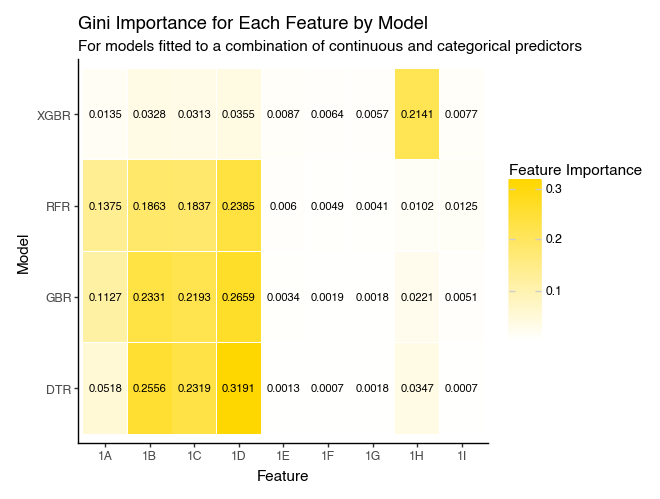

In [ ]:
from plotnine import *

figure_1 = (
    ggplot(
        data = concat_mod_set_1_condensed,
        mapping = aes(
            x = "Feature",
            y = "Model",
            fill = "Feature Importance"
        )
    ) +
        geom_tile(
            aes(
                width = 0.99,
                height = 0.99
            )
        ) +
        geom_text(
            aes(
                label = "Feature Importance"
            ),
            size = 8,
            show_legend = False
        ) +
        labs(
            title = "Gini Importance for Each Feature by Model",
            subtitle = "For models fitted to a combination of continuous and categorical predictors"
        ) +
        scale_fill_gradient2(
            low = "gray",
            high = "gold"
        ) +
        theme_classic()
)

figure_1

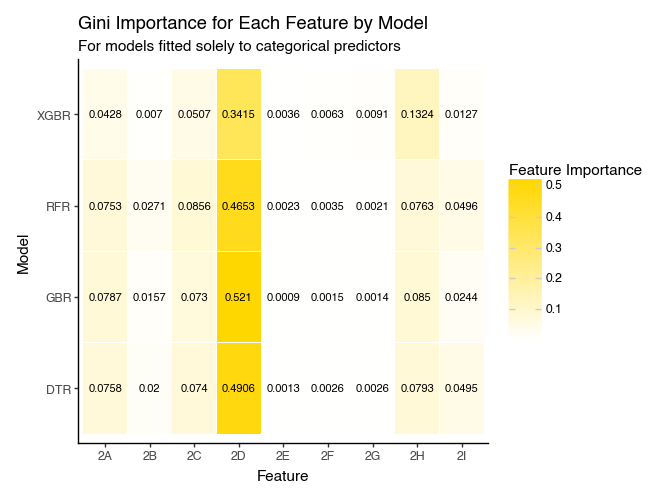

In [ ]:
figure_2 = (
    ggplot(
        data = concat_mod_set_2_condensed,
        mapping = aes(
            x = "Feature",
            y = "Model",
            fill = "Feature Importance"
        )
    ) +
        geom_tile(
            aes(
                width = 0.99,
                height = 0.99
            )
        ) +
        geom_text(
            aes(
                label = "Feature Importance"
            ),
            size = 8,
            show_legend = False
        ) +
        labs(
            title = "Gini Importance for Each Feature by Model",
            subtitle = "For models fitted solely to categorical predictors"
        ) +
        scale_fill_gradient2(
            low = "gray",
            high = "gold"
        ) +
        theme_classic()
)

figure_2